# Notebook 03 - Análise Exploratória de Dados (EDA)

## Objetivo

Gerar os insumos visuais e numéricos que fundamentam a modelagem por regressão linear múltipla apresentada na sequência, incluindo dispersão, correlação e heatmap

## Perguntas de diagnóstico

1. Existe relação linear aparente entre salário e anos de experiência?
2. Quais linguagens têm maior correlação com salário na amostra?
3. Como o salário se distribui entre países, áreas de atuação e níveis de formação?
4. Há padrões que antecipam achados ou problemas para o modelo do notebook 04?

## Entrada

- `data/processed/df_limpo.csv` (17.712 linhas × 33 colunas, gerado pelo notebook 02)

## Observação

Este notebook não modifica dados — apenas descreve e visualiza.

In [1]:
# Imports padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

# Configurações do pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Caminhos do projeto
DATA_PATH = Path("../data/processed/df_limpo.csv")
FIGURES_DIR = Path("../output/figures")
TABLES_DIR = Path("../output/tables")

# Garantir que diretórios de saída existem
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup concluído.")

Setup concluído.


In [2]:
# Carregamento do dataset limpo gerado pelo notebook 02
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Colunas: {len(df.columns)}")
print()
print("Primeiras linhas:")
df.head()

Shape: (17712, 33)
Colunas: 33

Primeiras linhas:


,ResponseId,MainBranch,EdLevel,Employment,YearsCode,DevType,Country,LanguageHaveWorkedWith,ConvertedCompYearly,log_salario,Country_agrupado,DevType_agrupado,EdLevel_agrupado,lang_JavaScript,lang_HTML_CSS,lang_SQL,lang_Python,lang_TypeScript,lang_Bash_Shell,lang_CSharp,lang_Java,lang_PowerShell,lang_CPlusPlus,lang_PHP,lang_Go,lang_C,lang_Rust,lang_Kotlin,lang_Lua,lang_Ruby,lang_Swift,lang_Dart,lang_Groovy
0,1,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",Ukraine,Bash/Shell (all shells);Dart;SQL,61256.0,11.022817,Ukraine,mobile,Mestrado,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end",Netherlands,Java,104413.0,11.556109,Netherlands,backend,Tecnólogo,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,3,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",12.0,"Developer, front-end",Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,53061.0,10.879197,Ukraine,frontend,Bacharelado,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,4,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,5.0,"Developer, back-end",Ukraine,Java;Kotlin;SQL,36197.0,10.496732,Ukraine,backend,Bacharelado,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
4,5,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",22.0,Engineering manager,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,60000.0,11.002100,Ukraine,outros,Mestrado,1,1,1,1,1,0,1,1,1,1,0,0,1,0,0,1,0,0,0,0


In [3]:
# Verificar se colunas agrupadas do nb 02 estão presentes
colunas_agrupadas = ["Country_agrupado", "DevType_agrupado", "EdLevel_agrupado"]
colunas_lang = [c for c in df.columns if c.startswith("lang_")]

print("Colunas agrupadas presentes:")
for col in colunas_agrupadas:
    existe = col in df.columns
    print(f"  {col}: {'✓' if existe else '✗ AUSENTE'}")

print(f"\nDummies de linguagem: {len(colunas_lang)} colunas")
print(f"  {colunas_lang}")

print(f"\nTotal de colunas: {df.shape[1]}")
print(f"Nomes de todas as colunas:\n{list(df.columns)}")

Colunas agrupadas presentes:
  Country_agrupado: ✓
  DevType_agrupado: ✓
  EdLevel_agrupado: ✓

Dummies de linguagem: 20 colunas
  ['lang_JavaScript', 'lang_HTML_CSS', 'lang_SQL', 'lang_Python', 'lang_TypeScript', 'lang_Bash_Shell', 'lang_CSharp', 'lang_Java', 'lang_PowerShell', 'lang_CPlusPlus', 'lang_PHP', 'lang_Go', 'lang_C', 'lang_Rust', 'lang_Kotlin', 'lang_Lua', 'lang_Ruby', 'lang_Swift', 'lang_Dart', 'lang_Groovy']

Total de colunas: 33
Nomes de todas as colunas:
['ResponseId', 'MainBranch', 'EdLevel', 'Employment', 'YearsCode', 'DevType', 'Country', 'LanguageHaveWorkedWith', 'ConvertedCompYearly', 'log_salario', 'Country_agrupado', 'DevType_agrupado', 'EdLevel_agrupado', 'lang_JavaScript', 'lang_HTML_CSS', 'lang_SQL', 'lang_Python', 'lang_TypeScript', 'lang_Bash_Shell', 'lang_CSharp', 'lang_Java', 'lang_PowerShell', 'lang_CPlusPlus', 'lang_PHP', 'lang_Go', 'lang_C', 'lang_Rust', 'lang_Kotlin', 'lang_Lua', 'lang_Ruby', 'lang_Swift', 'lang_Dart', 'lang_Groovy']


## 2. Dispersão: salário × anos de experiência

Dois gráficos lado a lado:

- **Esquerda:** salário bruto vs. YearsCode (escala linear no eixo Y)
- **Direita:** salário vs. YearsCode (escala log no eixo Y)

A comparação explicita por que a transformação logarítmica é considerada na etapa de modelagem a cauda longa de salários altos comprime a nuvem de pontos no gráfico linear, escondendo o padrão real da relação.

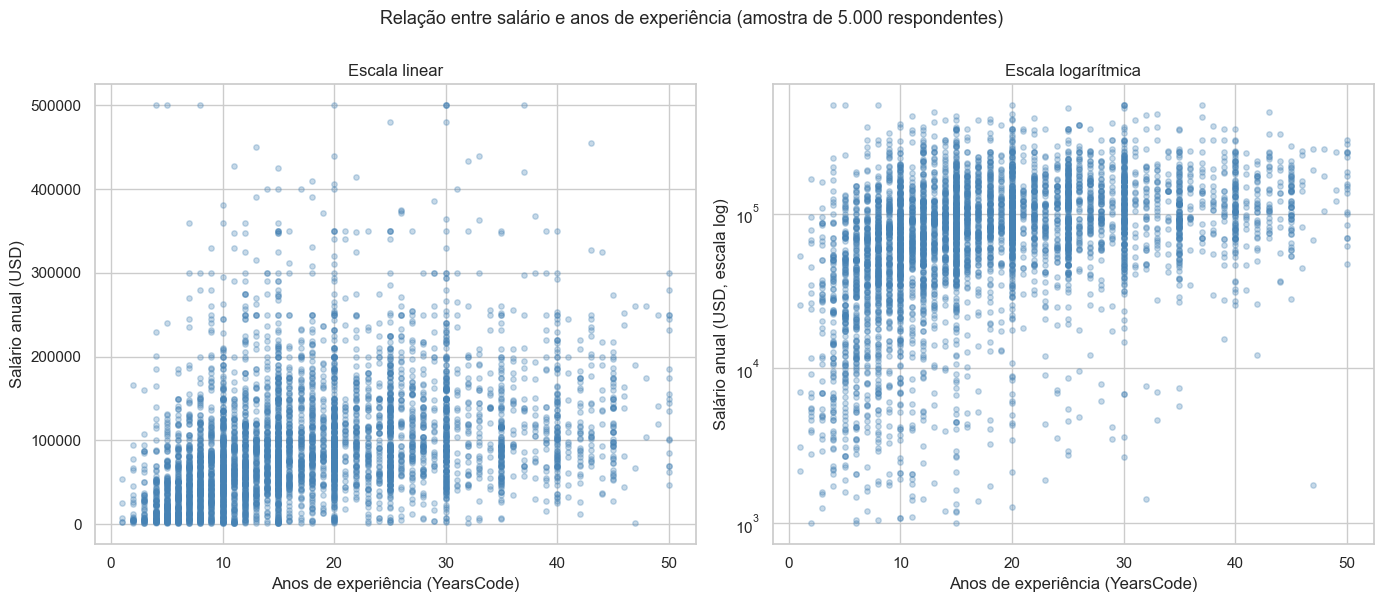

Gráfico salvo em: ..\output\figures\03_dispersao_salario_experiencia.png


In [4]:
# Dispersão salário × YearsCode (linear e log lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Amostra para evitar overplotting (17k pontos viram uma mancha preta)
amostra = df.sample(n=5000, random_state=42)

# Gráfico 1: escala linear
axes[0].scatter(
    amostra["YearsCode"],
    amostra["ConvertedCompYearly"],
    alpha=0.3,
    s=15,
    color="steelblue",
)
axes[0].set_xlabel("Anos de experiência (YearsCode)")
axes[0].set_ylabel("Salário anual (USD)")
axes[0].set_title("Escala linear")

# Gráfico 2: escala log no eixo Y
axes[1].scatter(
    amostra["YearsCode"],
    amostra["ConvertedCompYearly"],
    alpha=0.3,
    s=15,
    color="steelblue",
)
axes[1].set_yscale("log")
axes[1].set_xlabel("Anos de experiência (YearsCode)")
axes[1].set_ylabel("Salário anual (USD, escala log)")
axes[1].set_title("Escala logarítmica")

fig.suptitle(
    "Relação entre salário e anos de experiência (amostra de 5.000 respondentes)",
    fontsize=13,
    y=1.00,
)
plt.tight_layout()

# Salvar
output_path = FIGURES_DIR / "03_dispersao_salario_experiencia.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {output_path}")

## 3. Matriz de correlação e heatmap

A matriz inclui:

- `ConvertedCompYearly` (salário, variável dependente)
- `YearsCode` (anos de experiência, controle numérico)
- 20 dummies `lang_*` (linguagens, variáveis explicativas principais)

**Nota metodológica:** a correlação de Pearson entre uma variável contínua (salário) e uma dummy binária é matematicamente equivalente à correlação point-biserial. O coeficiente permanece interpretável como "quanto a presença da linguagem está associada a variação no salário", dentro dos limites de associação linear.

Dois artefatos são gerados:

- **Heatmap completo** (22×22) — visual para o relatório
- **Tabela ordenada** com a correlação de cada variável com salário — leitura analítica

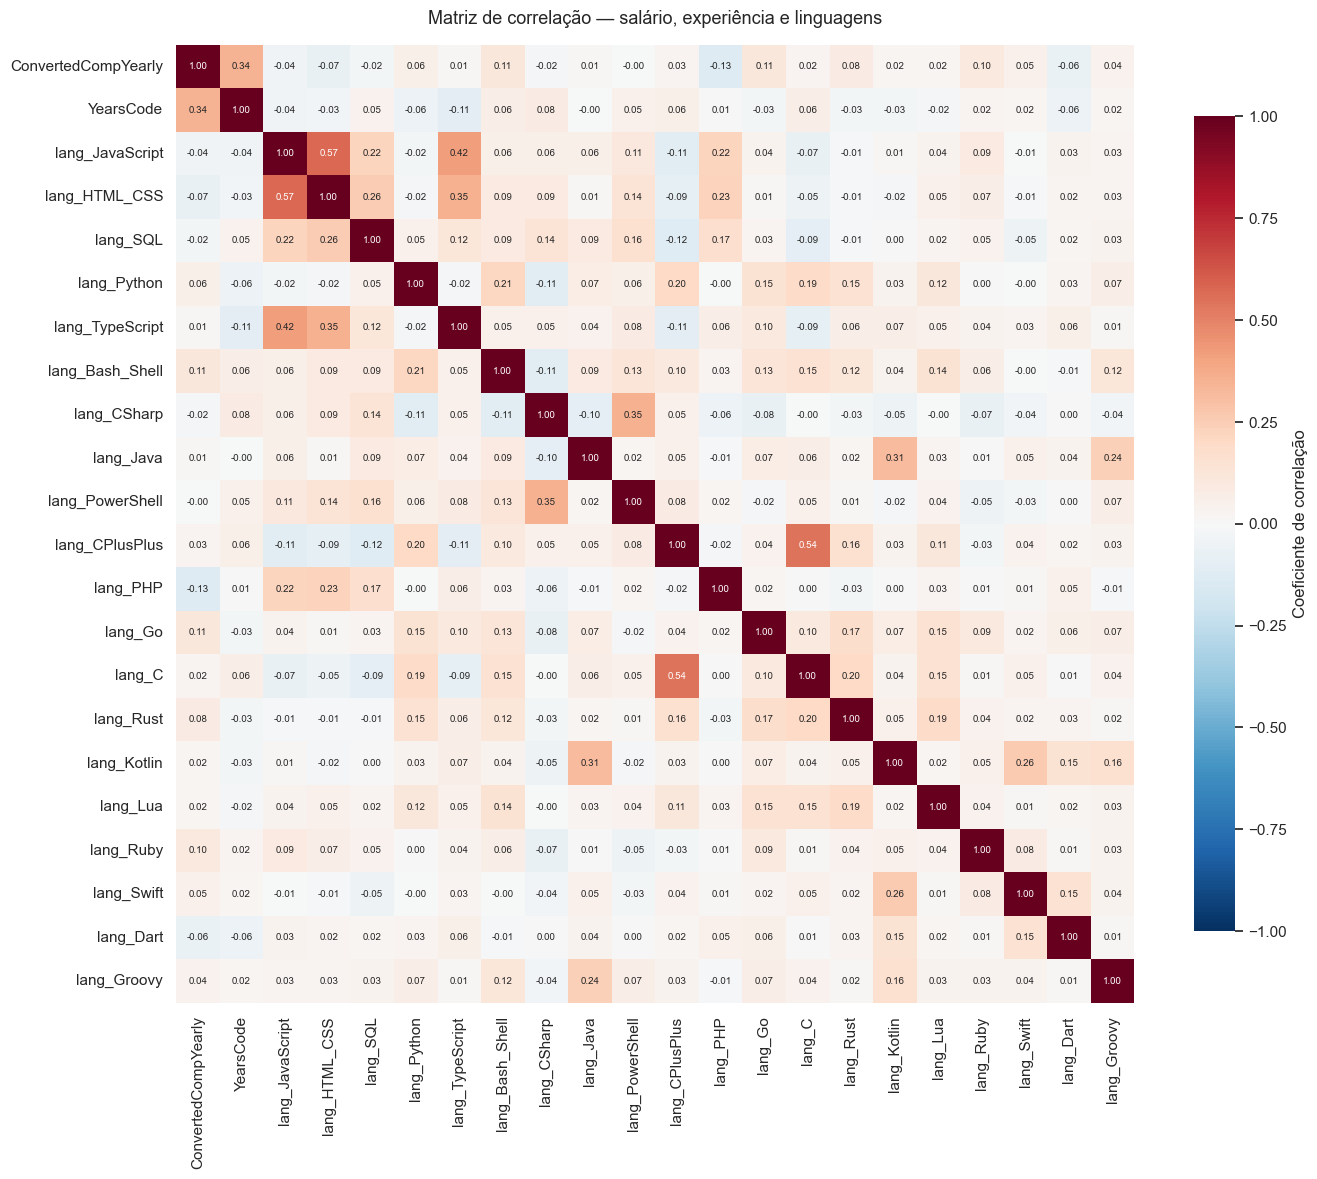

Heatmap salvo em: ..\output\figures\03_heatmap_correlacao.png


In [5]:
# Seleção das variáveis para a matriz
colunas_corr = ["ConvertedCompYearly", "YearsCode"] + [
    c for c in df.columns if c.startswith("lang_")
]

# Matriz de correlação de Pearson
matriz_corr = df[colunas_corr].corr()

# Heatmap completo
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de correlação"},
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title(
    "Matriz de correlação — salário, experiência e linguagens",
    fontsize=13,
    pad=15,
)
plt.tight_layout()

output_heatmap = FIGURES_DIR / "03_heatmap_correlacao.png"
plt.savefig(output_heatmap, bbox_inches="tight")
plt.show()

print(f"Heatmap salvo em: {output_heatmap}")

In [6]:
# Extrair a primeira coluna (correlação de tudo com salário), excluindo auto-correlação
corr_com_salario = (
    matriz_corr["ConvertedCompYearly"]
    .drop("ConvertedCompYearly")
    .sort_values(ascending=False)
    .to_frame(name="correlacao_com_salario")
)

# Adicionar coluna de magnitude absoluta para facilitar leitura
corr_com_salario["magnitude"] = corr_com_salario["correlacao_com_salario"].abs()
corr_com_salario = corr_com_salario.sort_values("magnitude", ascending=False)

# Salvar tabela
output_tabela = TABLES_DIR / "03_correlacao_com_salario.csv"
corr_com_salario.to_csv(output_tabela)

print("Correlação de cada variável com salário (ordenada por magnitude):\n")
print(corr_com_salario.round(3).to_string())
print(f"\nTabela salva em: {output_tabela}")

Correlação de cada variável com salário (ordenada por magnitude):

                 correlacao_com_salario  magnitude
YearsCode                         0.345      0.345
lang_PHP                         -0.131      0.131
lang_Bash_Shell                   0.114      0.114
lang_Go                           0.109      0.109
lang_Ruby                         0.099      0.099
lang_Rust                         0.081      0.081
lang_HTML_CSS                    -0.072      0.072
lang_Dart                        -0.064      0.064
lang_Python                       0.061      0.061
lang_Swift                        0.048      0.048
lang_JavaScript                  -0.043      0.043
lang_Groovy                       0.041      0.041
lang_CPlusPlus                    0.030      0.030
lang_C                            0.024      0.024
lang_SQL                         -0.024      0.024
lang_Lua                          0.021      0.021
lang_Kotlin                       0.020      0.020
lang_CSharp    

## 4. Distribuição do salário por país

Boxplot dos 10 países mais representados + categoria "Outros".

**Por que escala log neste gráfico:** a mediana salarial varia ~7x entre o topo (USA, $150k) e a base (Índia, $20k). Em escala linear, as caixas dos países mais baixos ficariam comprimidas próximas ao zero, ilegíveis. Esta é a única seção em que a transformação log é necessária para a leitura visual — as demais (linguagem, DevType, EdLevel) usam salário bruto.

O objetivo é visualizar a heterogeneidade salarial entre países insumo direto para a análise segmentada Brasil vs. global.

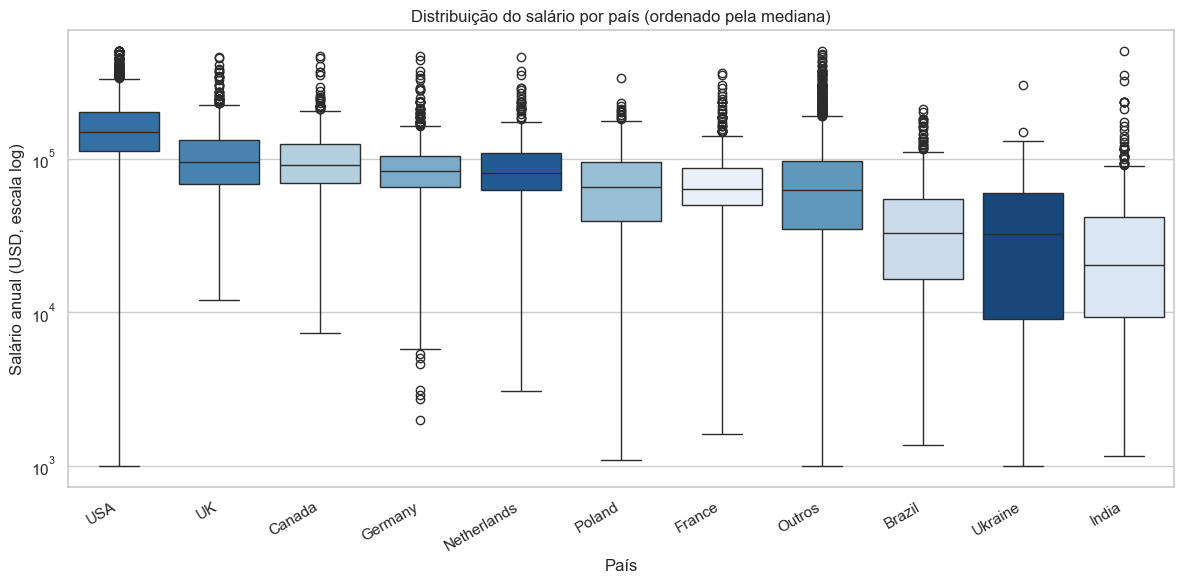

Estatísticas por país:

                     n   mediana     media  desvio_padrao
Country_agrupado                                         
USA               3919  150000.0  164437.0        77823.0
UK                1153   95299.0  108383.0        57044.0
Canada             708   91198.0  102924.0        53856.0
Germany           1583   83531.0   88931.0        40925.0
Netherlands        461   81210.0   92057.0        51051.0
Poland             462   64932.0   71263.0        44762.0
France             775   63808.0   74948.0        40828.0
Outros            6952   62893.0   71685.0        54253.0
Brazil             450   32767.0   43331.0        38111.0
Ukraine            479   32400.0   37501.0        32241.0
India              770   20342.0   31711.0        39271.0

Gráfico: ..\output\figures\03_boxplot_salario_por_pais.png
Tabela: ..\output\tables\03_salario_por_pais.csv


In [7]:
# Ordenar países pela mediana do salário (decrescente)
ordem_paises = (
    df.groupby("Country_agrupado")["ConvertedCompYearly"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Boxplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Country_agrupado",
    y="ConvertedCompYearly",
    order=ordem_paises,
    hue="Country_agrupado",
    palette="Blues_r",
    legend=False,
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("País")
ax.set_ylabel("Salário anual (USD, escala log)")
ax.set_title("Distribuição do salário por país (ordenado pela mediana)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "03_boxplot_salario_por_pais.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

# Tabela de estatísticas descritivas
tabela_pais = (
    df.groupby("Country_agrupado")["ConvertedCompYearly"]
    .agg(["count", "median", "mean", "std"])
    .round(0)
    .sort_values("median", ascending=False)
)
tabela_pais.columns = ["n", "mediana", "media", "desvio_padrao"]

output_tabela = TABLES_DIR / "03_salario_por_pais.csv"
tabela_pais.to_csv(output_tabela)

print("Estatísticas por país:\n")
print(tabela_pais.to_string())
print(f"\nGráfico: {output_path}")
print(f"Tabela: {output_tabela}")

## 5. Distribuição do salário por linguagem

Boxplot do salário comparando quem usa vs. quem não usa cada linguagem, para as 20 dummies `lang_*`.

Esta visualização antecipa, de forma marginal (sem controles), o tema central da pesquisa: quais linguagens estão associadas a salários mais altos. O modelo de regressão múltipla refinará essa leitura controlando por país, experiência e formação.

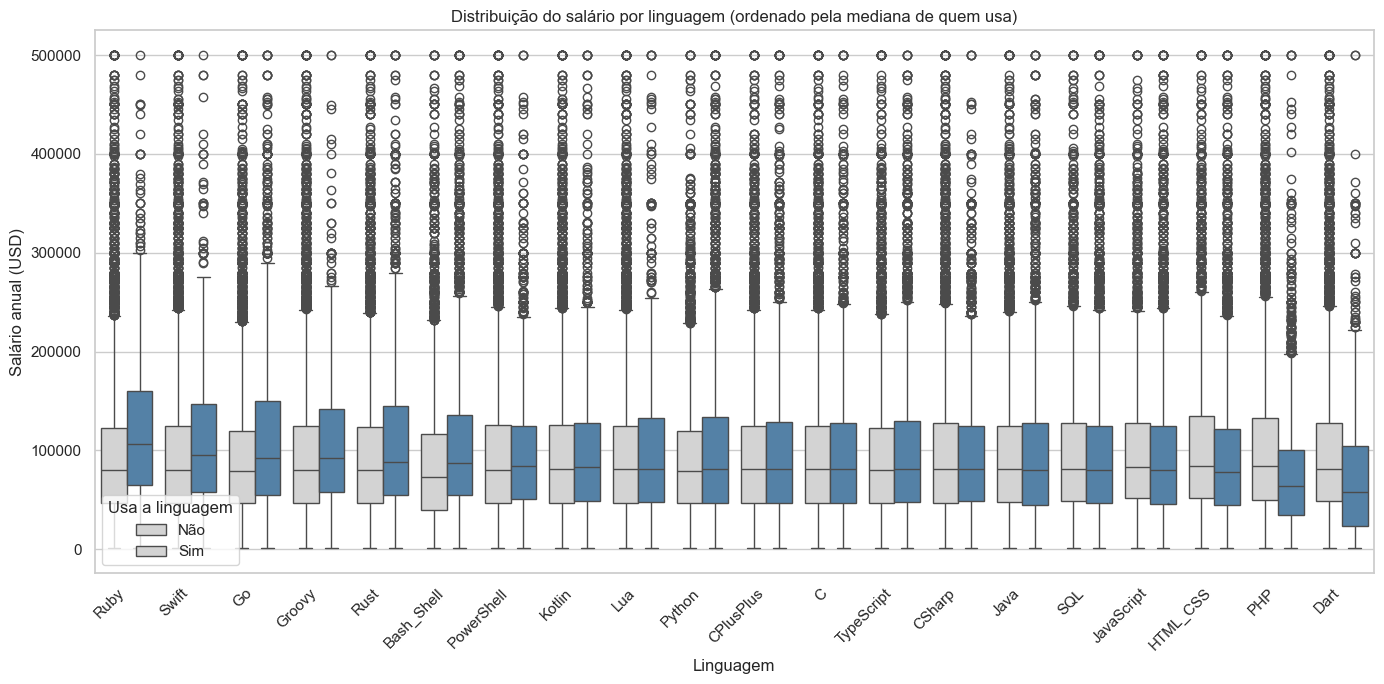

Salário por linguagem (ordenado por mediana de usuários):

            n_usuarios  mediana_usuarios  mediana_nao_usuarios  delta_mediana
Ruby              1286          106733.0               79911.0        26822.0
Swift              996           95066.0               80502.0        14564.0
Groovy             965           92812.0               80503.0        12309.0
Go                3113           92812.0               78890.0        13922.0
Rust              2472           88738.0               80000.0         8738.0
Bash_Shell        8855           87550.0               73089.0        14461.0
PowerShell        4229           84000.0               80000.0         4000.0
Kotlin            2023           83280.0               81210.0         2070.0
Lua               1442           81699.0               81210.0          489.0
CPlusPlus         3494           81685.0               81210.0          475.0
C                 2950           81685.0               81210.0          475.0
Pytho

In [8]:
# Para cada linguagem, comparar salário entre quem usa (1) e quem não usa (0)
# Estratégia: long-format com pd.melt para visualização
colunas_lang = [c for c in df.columns if c.startswith("lang_")]

# Calcular mediana salarial entre os usuários de cada linguagem (para ordenar)
medianas_lang = {
    col: df.loc[df[col] == 1, "ConvertedCompYearly"].median()
    for col in colunas_lang
}
ordem_lang = sorted(medianas_lang, key=medianas_lang.get, reverse=True)

# Long-format: cada linha vira (linguagem, usa_ou_nao, salario)
df_long = df.melt(
    id_vars=["ConvertedCompYearly"],
    value_vars=colunas_lang,
    var_name="linguagem",
    value_name="usa",
)
df_long["linguagem"] = df_long["linguagem"].str.replace("lang_", "")

# Mantém ordenação pela mediana de quem usa
df_long["linguagem"] = pd.Categorical(
    df_long["linguagem"],
    categories=[c.replace("lang_", "") for c in ordem_lang],
    ordered=True,
)

# Boxplot
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(
    data=df_long,
    x="linguagem",
    y="ConvertedCompYearly",
    hue="usa",
    palette={0: "lightgray", 1: "steelblue"},
    ax=ax,
)
ax.set_xlabel("Linguagem")
ax.set_ylabel("Salário anual (USD)")
ax.set_title(
    "Distribuição do salário por linguagem (ordenado pela mediana de quem usa)"
)
ax.legend(title="Usa a linguagem", labels=["Não", "Sim"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "03_boxplot_salario_por_linguagem.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

# Tabela: mediana e n de quem usa cada linguagem
tabela_lang = pd.DataFrame({
    "n_usuarios": [int(df[col].sum()) for col in colunas_lang],
    "mediana_usuarios": [
        df.loc[df[col] == 1, "ConvertedCompYearly"].median() for col in colunas_lang
    ],
    "mediana_nao_usuarios": [
        df.loc[df[col] == 0, "ConvertedCompYearly"].median() for col in colunas_lang
    ],
}, index=[c.replace("lang_", "") for c in colunas_lang])

tabela_lang["delta_mediana"] = (
    tabela_lang["mediana_usuarios"] - tabela_lang["mediana_nao_usuarios"]
)
tabela_lang = tabela_lang.sort_values("mediana_usuarios", ascending=False).round(0)

output_tabela = TABLES_DIR / "03_salario_por_linguagem.csv"
tabela_lang.to_csv(output_tabela)

print("Salário por linguagem (ordenado por mediana de usuários):\n")
print(tabela_lang.to_string())
print(f"\nGráfico: {output_path}")
print(f"Tabela: {output_tabela}")

## 6. Distribuição do salário por área de atuação (DevType)

Boxplot do salário pelas 6 macro-categorias de `DevType_agrupado` definidas na etapa de tratamento dos dados.

Insumo direto para a análise segmentada por área de atuação (backend, frontend, fullstack, mobile).

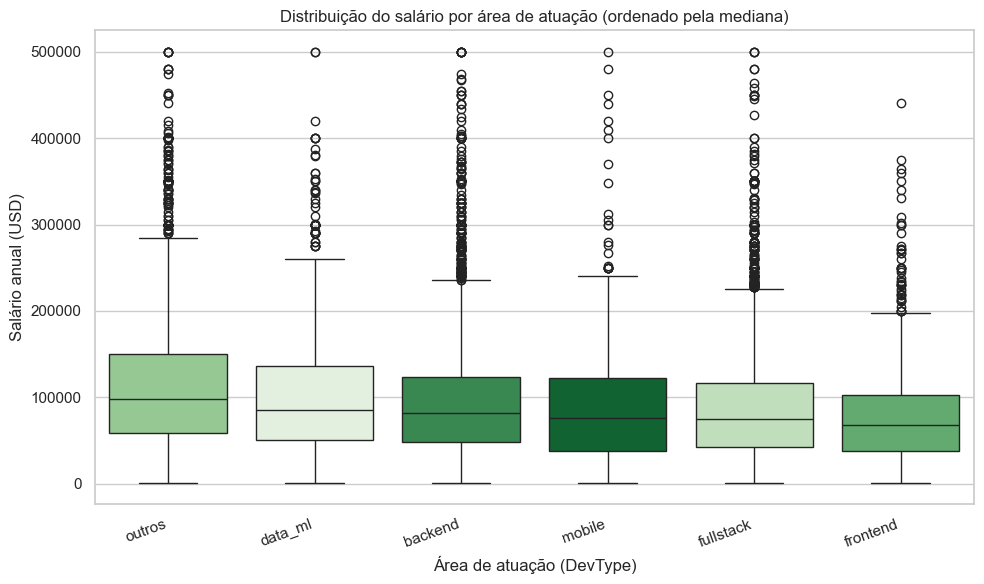

Estatísticas por DevType:

                     n  mediana     media  desvio_padrao
DevType_agrupado                                        
outros            3541  97514.0  113057.0        78169.0
data_ml           1111  84691.0  101340.0        75950.0
backend           5050  81210.0   94688.0        70742.0
mobile             626  76326.0   90158.0        74869.0
fullstack         6467  75000.0   85987.0        62668.0
frontend           917  68071.0   79728.0        63238.0

Gráfico: ..\output\figures\03_boxplot_salario_por_devtype.png
Tabela: ..\output\tables\03_salario_por_devtype.csv


In [10]:
# Ordenar DevType pela mediana
ordem_devtype = (
    df.groupby("DevType_agrupado")["ConvertedCompYearly"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="DevType_agrupado",
    y="ConvertedCompYearly",
    order=ordem_devtype,
    hue="DevType_agrupado",
    palette="Greens_r",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Área de atuação (DevType)")
ax.set_ylabel("Salário anual (USD)")
ax.set_title("Distribuição do salário por área de atuação (ordenado pela mediana)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "03_boxplot_salario_por_devtype.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

# Tabela
tabela_devtype = (
    df.groupby("DevType_agrupado")["ConvertedCompYearly"]
    .agg(["count", "median", "mean", "std"])
    .round(0)
    .sort_values("median", ascending=False)
)
tabela_devtype.columns = ["n", "mediana", "media", "desvio_padrao"]

output_tabela = TABLES_DIR / "03_salario_por_devtype.csv"
tabela_devtype.to_csv(output_tabela)

print("Estatísticas por DevType:\n")
print(tabela_devtype.to_string())
print(f"\nGráfico: {output_path}")
print(f"Tabela: {output_tabela}")

## 7. Salário mediano por nível de formação (EdLevel)

Diferente das seções anteriores, aqui usamos um gráfico de barras (mediana por categoria) em vez de boxplot. A justificativa: `EdLevel_agrupado` tem ordem natural (Fundamental < Médio < Tecnólogo < Bacharelado < Mestrado < Doutorado), e barras ordenadas tornam a tendência mais legível.

Insumo para o controle `EdLevel_agrupado` no modelo de regressão.

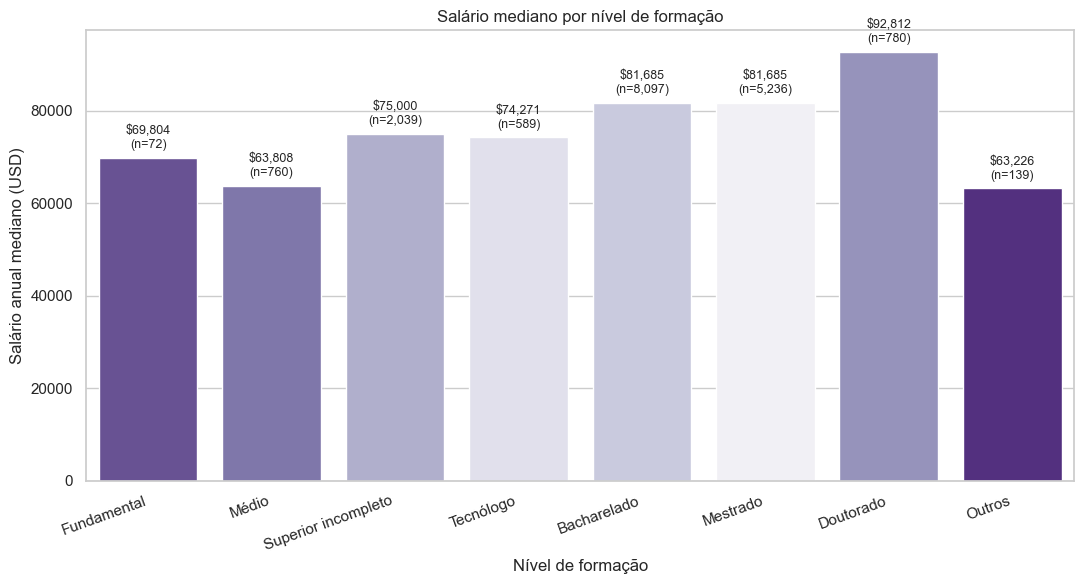

Estatísticas por nível de formação:

                        n  mediana     media  desvio_padrao
EdLevel_agrupado                                           
Fundamental            72  69804.0   89140.0        85889.0
Médio                 760  63808.0   75486.0        59327.0
Superior incompleto  2039  75000.0   90024.0        69258.0
Tecnólogo             589  74271.0   88878.0        64244.0
Bacharelado          8097  81685.0   95612.0        72813.0
Mestrado             5236  81685.0   96520.0        67315.0
Doutorado             780  92812.0  112148.0        77824.0
Outros                139  63226.0   71989.0        51851.0

Gráfico: ..\output\figures\03_barras_salario_por_edlevel.png
Tabela: ..\output\tables\03_salario_por_edlevel.csv


In [12]:
# Ordem pedagógica esperada (do menor para o maior nível)
ordem_edlevel = [
    "Fundamental",
    "Médio",
    "Superior incompleto",
    "Tecnólogo",
    "Bacharelado",
    "Mestrado",
    "Doutorado",
    "Outros",
]

# Filtrar apenas categorias presentes no df (caso alguma esteja vazia)
ordem_edlevel = [c for c in ordem_edlevel if c in df["EdLevel_agrupado"].unique()]

# Tabela de medianas
tabela_edlevel = (
    df.groupby("EdLevel_agrupado")["ConvertedCompYearly"]
    .agg(["count", "median", "mean", "std"])
    .round(0)
    .reindex(ordem_edlevel)
)
tabela_edlevel.columns = ["n", "mediana", "media", "desvio_padrao"]

# Gráfico de barras (mediana)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=df,
    x="EdLevel_agrupado",
    y="ConvertedCompYearly",
    order=ordem_edlevel,
    hue="EdLevel_agrupado",
    estimator=np.median,
    errorbar=None,
    palette="Purples",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Nível de formação")
ax.set_ylabel("Salário anual mediano (USD)")
ax.set_title("Salário mediano por nível de formação")
plt.xticks(rotation=20, ha="right")

# Anotar valor no topo de cada barra
for i, categoria in enumerate(ordem_edlevel):
    mediana = tabela_edlevel.loc[categoria, "mediana"]
    n = int(tabela_edlevel.loc[categoria, "n"])
    ax.text(
        i,
        mediana + 1500,
        f"${mediana:,.0f}\n(n={n:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
output_path = FIGURES_DIR / "03_barras_salario_por_edlevel.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

# Salvar tabela
output_tabela = TABLES_DIR / "03_salario_por_edlevel.csv"
tabela_edlevel.to_csv(output_tabela)

print("Estatísticas por nível de formação:\n")
print(tabela_edlevel.to_string())
print(f"\nGráfico: {output_path}")
print(f"Tabela: {output_tabela}")

## 8. Conclusões da análise exploratória

A análise descritiva dos 17.712 respondentes revelou padrões relevantes para a modelagem subsequente.

**Relação salário × experiência.** O coeficiente de correlação de Pearson entre salário anual e anos de código é de 0,34 — associação positiva moderada, consistente com a expectativa teórica. O diagrama de dispersão em escala logarítmica evidencia retornos decrescentes da experiência: o salário cresce com `YearsCode` até aproximadamente 20 anos de carreira e tende a estabilizar depois.

**Correlações marginais das linguagens.** Nenhuma linguagem isolada apresenta correlação forte com salário. As maiores magnitudes observadas foram PHP (-0,13), Bash/Shell (0,11) e Go (0,11). Esse resultado é esperado em variáveis dummy e reforça a necessidade de um modelo multivariado: efeitos reais das linguagens só emergem após controlar simultaneamente por país, formação e experiência.

**Heterogeneidade entre países.** A mediana salarial varia por um fator de sete entre os países da amostra — Estados Unidos (USD 150.000) no topo e Índia (USD 20.342) na base. Brasil ocupa posição intermediária-baixa (USD 32.767, n=450), amostra suficiente para a análise segmentada por país. A magnitude dessa heterogeneidade antecipa que `Country` será a variável de controle mais influente no modelo global.

**Diferenças por área de atuação.** Entre as seis macrocategorias de DevType, observa-se hierarquia salarial compatível com a percepção de mercado: backend (USD 81.210) acima de fullstack (USD 75.000), com frontend (USD 68.071) na base das áreas técnicas clássicas. A categoria "outros" apresenta a maior mediana (USD 97.514), resultado do agrupamento de cargos gerenciais e sêniores que serão tratados no modelo.

**Retornos à formação.** O salário mediano cresce de forma consistente do Superior incompleto (USD 75.000) ao Doutorado (USD 92.812), com estabilidade entre Bacharelado e Mestrado (ambos USD 81.685). A presença de níveis não-monotônicos nos extremos inferiores (Fundamental acima de Médio) provavelmente reflete efeito de coorte que será absorvido pelo controle de `YearsCode` no modelo.

**Próximos passos.** Os achados desta etapa confirmam a adequação das variáveis selecionadas e antecipam dois pontos metodológicos para a etapa de modelagem: a presença de correlações entre linguagens (JavaScript × HTML/CSS: 0,57; C++ × C: 0,54) que podem gerar multicolinearidade e devem ser diagnosticadas via VIF; e a escolha de categorias de referência para as variáveis categóricas, que determina a leitura dos coeficientes do modelo.